Testing de algunos modelos

In [74]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, KFold, RandomizedSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, make_scorer
from sklearn.inspection import permutation_importance
from sklearn.preprocessing import RobustScaler
from sklearn.linear_model import ElasticNetCV, Ridge
from sklearn.ensemble import RandomForestRegressor, StackingRegressor

from xgboost import XGBRegressor
import xgboost as xgb
from lightgbm import LGBMRegressor, Dataset
import lightgbm as lgb
from catboost import CatBoostRegressor
import optuna
import shap
import pandas as pd
import numpy as np
from sklearn.model_selection import GridSearchCV, KFold
from sklearn.metrics import make_scorer, mean_absolute_error
from xgboost import XGBRegressor

import optuna
from sklearn.model_selection import cross_val_score


In [75]:
df_prep = pd.read_csv('../data/processed/BC_A&A_with_ATD_prep.csv', index_col=0)

In [76]:
df_prep.columns

Index(['day_of_week', 'is_weekend', 'ATD_log', 'rest_offer_missing',
       'pickup_distance_nan', 'sin_hour', 'cos_hour', 'hora_pico_ordenes',
       'hora_pico_atd', 'pickup_distance_log', 'dropoff_distance_log',
       'courier_Logistics', 'courier_Motorbike', 'courier_Onboarder',
       'courier_SUV', 'courier_UberEats', 'courier_UberX', 'geo_Defend_CP',
       'geo_Drive momentum', 'geo_Play offense', 'geo_Unlaunched',
       'geo_Unspecified', 'surface_POS', 'surface_Tablet',
       'surface_Unspecified', 'surface_Web/Mobile',
       'territory_Long Tail - Region', 'territory_North',
       'territory_South East', 'territory_West',
       'pickup_dropoff_ratio_winsor_log', 'hour_bin_04-08', 'hour_bin_08-12',
       'hour_bin_12-16', 'hour_bin_16-20', 'hour_bin_20-24',
       'driver_orders_category_high', 'driver_orders_category_low',
       'driver_orders_category_medium', 'driver_orders_category_novice',
       'driver_orders_category_unassigned'],
      dtype='object')

In [77]:
target = 'ATD_log'
X = df_prep.drop(columns=[target]).copy()
y = df_prep[target].copy()

X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42)

cv = KFold(n_splits=5, shuffle=True, random_state=42)
mae_scorer = make_scorer(mean_absolute_error, greater_is_better=False)

In [56]:

xgb_model = XGBRegressor(
    n_estimators=300,
    learning_rate=0.1,
    max_depth=6,
    random_state=42
)

In [57]:

xgb_model.fit(X_train, y_train)

xgb_cv_scores = cross_val_score(
    xgb_model, X_train, y_train, cv=cv,
      scoring=mae_scorer
)

xgb_test_mae = mean_absolute_error(y_test, xgb_model.predict(X_test))

xgb_importances = xgb_model.feature_importances_

In [58]:
xgb_test_mae

0.2828774594575784

In [ ]:
X = df_prep.drop(columns=[target])
y = df_prep[target]

mae_scorer = make_scorer(mean_absolute_error, greater_is_better=False)


In [71]:
# primer test de optuna
def objective(trial):
    params = {
        'n_estimators': 300,
        'max_depth': trial.suggest_int('max_depth', 3, 15),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.5, log=True),
        'subsample': trial.suggest_float('subsample', 0, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.2, 1.0),
        'reg_alpha': trial.suggest_float('reg_alpha', 0.0, 1.2),
        'reg_lambda': trial.suggest_float('reg_lambda', 0.5, 3.0),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
        'random_state': 42
    }

    model = XGBRegressor(**params)
    cv = KFold(n_splits=5)
    scores = cross_val_score(model, X, y, cv=cv, scoring=mae_scorer, n_jobs=-1)
    return -np.mean(scores)

In [ ]:

study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=50)

print("Best parameters found: ", study.best_params)
print("Best MAE score: ", study.best_value)


[I 2025-05-31 16:14:39,136] A new study created in memory with name: no-name-ed0c4360-f41c-4ab5-b980-4b63125400bb
[I 2025-05-31 16:14:55,899] Trial 0 finished with value: 0.28988931209825636 and parameters: {'max_depth': 4, 'learning_rate': 0.018425267390729912, 'subsample': 0.6951430755605061, 'colsample_bytree': 0.7620744016481393, 'reg_alpha': 0.94815925057894, 'reg_lambda': 1.9094637489219455, 'min_child_weight': 7}. Best is trial 0 with value: 0.28988931209825636.
[I 2025-05-31 16:15:21,428] Trial 1 finished with value: 0.29114658885938444 and parameters: {'max_depth': 10, 'learning_rate': 0.2935609467489844, 'subsample': 0.9109041536707897, 'colsample_bytree': 0.684650219545191, 'reg_alpha': 0.5713954477056002, 'reg_lambda': 1.5926333470147416, 'min_child_weight': 1}. Best is trial 0 with value: 0.28988931209825636.
[I 2025-05-31 16:15:47,486] Trial 2 finished with value: 0.28373474847210084 and parameters: {'max_depth': 10, 'learning_rate': 0.08780801497608015, 'subsample': 0.69

Best parameters found:  {'max_depth': 9, 'learning_rate': 0.053063667959215785, 'subsample': 0.9424827068160501, 'colsample_bytree': 0.8181958016055538, 'reg_alpha': 1.1919263859193818, 'reg_lambda': 2.9934022301042242, 'min_child_weight': 2}
Best MAE score:  0.2824727875415813


In [59]:
best_params = {'max_depth': 9, 'learning_rate': 0.053063667959215785, 'subsample': 0.9424827068160501, 'colsample_bytree': 0.8181958016055538, 'reg_alpha': 1.1919263859193818, 'reg_lambda': 2.9934022301042242, 'min_child_weight': 2}

Modelo prometedor como base 


{'max_depth': 9, 'learning_rate': 0.053063667959215785, 'subsample': 0.9424827068160501, 'colsample_bytree': 0.8181958016055538, 'reg_alpha': 1.1919263859193818, 'reg_lambda': 2.9934022301042242, 'min_child_weight': 2}

In [16]:
error = np.exp(study.best_value) - 1
print(error*100)

32.6405679846222


In [60]:
model = XGBRegressor(**best_params)
model.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8181958016055538, device=None,
             early_stopping_rounds=None, enable_categorical=False,
             eval_metric=None, feature_types=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.053063667959215785, max_bin=None,
             max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=9, max_leaves=None,
             min_child_weight=2, missing=nan, monotone_constraints=None,
             multi_strategy=None, n_estimators=None, n_jobs=None,
             num_parallel_tree=None, random_state=None, ...)

In [61]:
model.get_booster().get_score(importance_type='gain')
importance = model.get_booster().get_score(importance_type='gain')
importance = sorted(importance.items(), key=lambda x: x[1], reverse=True)
importance_df = pd.DataFrame(importance, columns=['feature', 'gain'])

In [62]:
importance_df

,feature,gain
0,driver_orders_category_unassigned,371.629730
1,pickup_distance_nan,119.991196
2,courier_UberEats,75.685036
3,dropoff_distance_log,62.967438
4,surface_Unspecified,28.064838
5,rest_offer_missing,21.451397
6,territory_North,20.166582
7,courier_Motorbike,19.978714
8,pickup_distance_log,15.019580
9,surface_POS,12.427106


In [63]:
scaler = RobustScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

reg = xgb.XGBRegressor(**best_params)
reg.fit(X_train, y_train)


XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8181958016055538, device=None,
             early_stopping_rounds=None, enable_categorical=False,
             eval_metric=None, feature_types=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.053063667959215785, max_bin=None,
             max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=9, max_leaves=None,
             min_child_weight=2, missing=nan, monotone_constraints=None,
             multi_strategy=None, n_estimators=None, n_jobs=None,
             num_parallel_tree=None, random_state=None, ...)

In [72]:
# probar optuna con datos escalados
X = X_scaled.copy()
study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=50)

print("Best parameters found: ", study.best_params)
print("Best MAE score: ", study.best_value)

[I 2025-05-31 21:56:09,586] A new study created in memory with name: no-name-8c06081b-9eba-4abc-865e-8d2a89713cd8
[I 2025-05-31 21:56:50,322] Trial 0 finished with value: 0.2859271086462188 and parameters: {'max_depth': 13, 'learning_rate': 0.060451672705682066, 'subsample': 0.17896472609479286, 'colsample_bytree': 0.47519090577364614, 'reg_alpha': 1.1583235735673583, 'reg_lambda': 1.1708568619928126, 'min_child_weight': 7}. Best is trial 0 with value: 0.2859271086462188.
[I 2025-05-31 21:57:34,956] Trial 1 finished with value: 0.2853398430724777 and parameters: {'max_depth': 14, 'learning_rate': 0.024456828804103752, 'subsample': 0.22768070047164013, 'colsample_bytree': 0.35371334420534223, 'reg_alpha': 0.7350719851442724, 'reg_lambda': 1.269415436929819, 'min_child_weight': 7}. Best is trial 1 with value: 0.2853398430724777.
[I 2025-05-31 21:58:01,794] Trial 2 finished with value: 0.2982738443072695 and parameters: {'max_depth': 10, 'learning_rate': 0.2342569710181804, 'subsample': 0

Best parameters found:  {'max_depth': 10, 'learning_rate': 0.02974373631888332, 'subsample': 0.819613785618151, 'colsample_bytree': 0.909620616196565, 'reg_alpha': 0.7440108710739888, 'reg_lambda': 0.7843618954857372, 'min_child_weight': 2}
Best MAE score:  0.28261027066793964


Empeoró el modelo utilizando los datos escalados. Por ende, aunque es un modelo mediocre, por tener algo, usemos el orginal

Mean Absolute Error (MAE): 0.2836
Root Mean Squared Error (RMSE): 0.3942
R-squared (R²): 0.4073


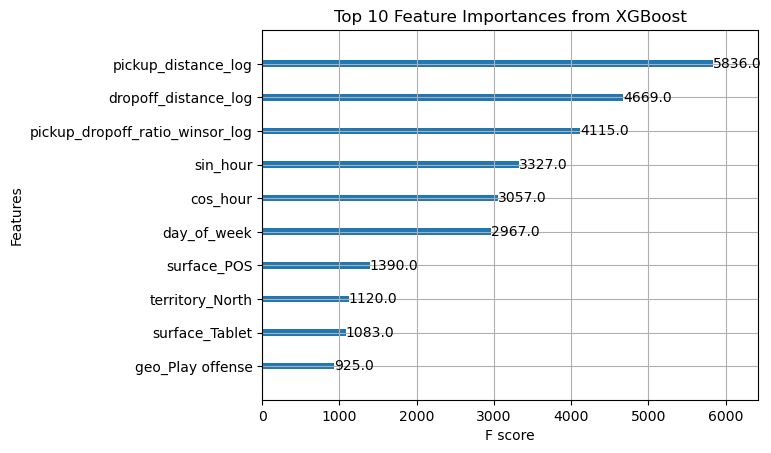

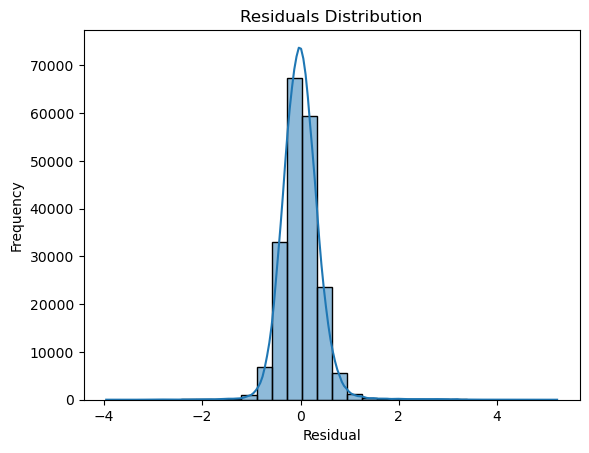

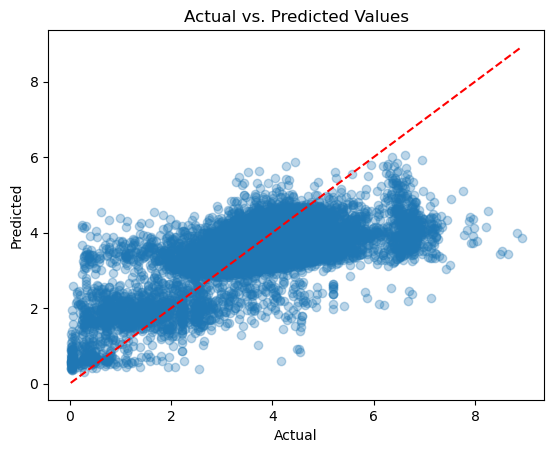

In [81]:
target = 'ATD_log'
X = df_prep.drop(columns=[target]).copy()
y = df_prep[target].copy()

X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42)

cv = KFold(n_splits=5, shuffle=True, random_state=42)
mae_scorer = make_scorer(mean_absolute_error, greater_is_better=False)

model = XGBRegressor(**best_params)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"Mean Absolute Error (MAE): {mae:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
print(f"R-squared (R²): {r2:.4f}")

model.fit(X_train, y_train)
xgb.plot_importance(model, max_num_features=10)
plt.title('Top 10 Feature Importances from XGBoost')
plt.show()

residuals = y_test - y_pred
sns.histplot(residuals, bins=30, kde=True)
plt.title('Residuals Distribution')
plt.xlabel('Residual')
plt.ylabel('Frequency')
plt.show()

plt.scatter(y_test, y_pred, alpha=0.3)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.title('Actual vs. Predicted Values')
plt.show()